# Text Representation and Classical Text Classification

This notebook develops text classification from raw text to numerical features. The main progression is:

```text
Raw text
→ cleaning
→ tokenization
→ vocabulary
→ word-count representation
→ feature engineering
→ text classification
```

The data consist of paragraphs taken from Project Gutenberg books. The classification task is to determine which book a paragraph came from.


## Part 1: Manual Cleaning, Tokenization, Vocabulary, and Word Counts

This first workflow makes the representation steps explicit. It shows how raw paragraphs become cleaned tokens, how a vocabulary is created, and how each paragraph becomes a numerical word-count vector.


We will download 4 books:

* The Call of the Wild, by Jack London
* Dracula, by Bram Stoker
* The Adventures of Sherlock Holmes, by Arthur Conan Doyle
* Twenty Thousand Leagues under the Sea, by Jules Verne

We will split the books into a collection of paragraphs and train a machine learning model to determine the book a paragraph was taken from.


### Import Libraries


In [1]:
import bs4 as bs
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

import tensorflow as tf

### Raw Text Collection


In [2]:
def get_paragraph_list(url,skip):
    paragraphs = []
    data = urllib.request.urlopen(url).read()
    soup = bs.BeautifulSoup(data,'lxml')
    for paragraph in soup.find_all('p'):
        par  = paragraph.get_text()
        if par:
            if len(par)>=5:
              paragraphs.append(par)
    return paragraphs[skip:]


url_list = ['http://www.gutenberg.org/files/215/215-h/215-h.htm', 'http://www.gutenberg.org/files/345/345-h/345-h.htm',
            'http://www.gutenberg.org/files/1661/1661-h/1661-h.htm','https://www.gutenberg.org/files/164/164-h/164-h.htm']

books = [215,345,1661,164]
url_list = [f'http://www.gutenberg.org/files/{i}/{i}-h/{i}-h.htm' for  i in books]

paragraphs = []
targets = []
first_par = []
skip = [1,5,1,0]
for u, url in enumerate(url_list):
    par = get_paragraph_list(url,skip[u])
    paragraphs = paragraphs + par
    targets = targets + [u for i in par]
    print('\nBook {} contains {} paragraphs'.format(u,len(par)))
    lengths = np.array([len(wl) for wl in par])
    print('Paragraph length stats:')
    print('min = {} max = {} mean = {:4f}'.format(np.min(lengths),np.max(lengths),np.mean(lengths)))
    print('First paragraph:')
    print(par[0])

targets = np.array(targets)



Book 0 contains 330 paragraphs
Paragraph length stats:
min = 14 max = 1558 mean = 529.842424
First paragraph:

Buck did not read the newspapers, or he would have known that trouble was
brewing, not alone for himself, but for every tide-water dog, strong of muscle
and with warm, long hair, from Puget Sound to San Diego. Because men, groping
in the Arctic darkness, had found a yellow metal, and because steamship and
transportation companies were booming the find, thousands of men were rushing
into the Northland. These men wanted dogs, and the dogs they wanted were heavy
dogs, with strong muscles by which to toil, and furry coats to protect them
from the frost.


Book 1 contains 1944 paragraphs
Paragraph length stats:
min = 6 max = 4713 mean = 426.958848
First paragraph:
3 May. Bistritz.—Left Munich at 8:35 P. M., on 1st May, arriving at
Vienna early next morning; should have arrived at 6:46, but train was an
hour late. Buda-Pesth seems a wonderful place, from the glimpse which I
got of 

In [3]:
p = np.random.randint(0,len(paragraphs))
print(paragraphs[p])

“Where poor Lucy is buried?” The Professor bowed. Arthur went on: “And
when there?”


### Cleaning and Tokenization

The paragraphs are tokenized with `wordpunct_tokenize`. The cleaning step converts words to lowercase and keeps tokens composed only of letters. Very short token sequences are removed.

This makes the transformation from raw text to cleaned tokens explicit.


In [4]:
len(paragraphs)

7102

In [5]:
from nltk.tokenize import wordpunct_tokenize

p_tok = [wordpunct_tokenize(p) for p in paragraphs]

letters = set(chr(c) for c in range(ord('a'),ord('z')+1))
par_tokens = []
par_targets = []
min_len = 3

for i in range(len(p_tok)):
  p = [w.lower() for w in p_tok[i]]
  p = [w for w in p if len(set(w).difference(letters))==0]
  if len(p) >=min_len:
    par_tokens.append(p)
    par_targets.append(targets[i])

In [6]:
print(par_tokens[0])

['buck', 'did', 'not', 'read', 'the', 'newspapers', 'or', 'he', 'would', 'have', 'known', 'that', 'trouble', 'was', 'brewing', 'not', 'alone', 'for', 'himself', 'but', 'for', 'every', 'tide', 'water', 'dog', 'strong', 'of', 'muscle', 'and', 'with', 'warm', 'long', 'hair', 'from', 'puget', 'sound', 'to', 'san', 'diego', 'because', 'men', 'groping', 'in', 'the', 'arctic', 'darkness', 'had', 'found', 'a', 'yellow', 'metal', 'and', 'because', 'steamship', 'and', 'transportation', 'companies', 'were', 'booming', 'the', 'find', 'thousands', 'of', 'men', 'were', 'rushing', 'into', 'the', 'northland', 'these', 'men', 'wanted', 'dogs', 'and', 'the', 'dogs', 'they', 'wanted', 'were', 'heavy', 'dogs', 'with', 'strong', 'muscles', 'by', 'which', 'to', 'toil', 'and', 'furry', 'coats', 'to', 'protect', 'them', 'from', 'the', 'frost']


### Vocabulary Construction

The cleaned tokens are counted and sorted by frequency. The vocabulary gives each retained word a fixed column position in the document representation.

The manual workflow below is useful for understanding how a word-count matrix is constructed. For strict held-out evaluation, a vocabulary should be fitted only on the training text. The later `CountVectorizer` workflow demonstrates that train-fitted procedure directly.


In [7]:
count = {}

for p in par_tokens:
  for w in p:
    count[w] = count.get(w,0)+1

vocabulary = list(count.keys())
frequencies = list(count.values())

a = np.argsort(frequencies)[::-1]
vocabulary = [vocabulary[i] for i in a]

index = {}
for i,w in enumerate(vocabulary):
    index[w] = i

word_counts = np.zeros((len(par_tokens),len(vocabulary)),dtype=np.int16)


In [8]:
vocabulary[:10]

['the', 'and', 'of', 'to', 'i', 'a', 'in', 'that', 'it', 'he']

In [9]:
for w in vocabulary[:10]:
  print(w, index[w])

the 0
and 1
of 2
to 3
i 4
a 5
in 6
that 7
it 8
he 9


In [10]:
vocabulary[-10:]

['lyin',
 'grup',
 'approval',
 'yabblins',
 'poorish',
 'hecatomb',
 'brewing',
 'cretan',
 'enormously',
 'undefinable']

In [11]:
word_counts.shape

(6849, 17143)

In [12]:
len(vocabulary)

17143

### Build the Word-Count Matrix

Fill out the `word_counts` array. Notice the following:

1. **word_counts.shape[0]** is the number of documents in the dataset.
2. **word_counts.shape[1]** is the number of words in the vocabulary.
3. **word_counts[i,j]** is the number of times word j appears in paragraph i.
4. **par_tokens[i]** is the list of words that appear in paragraph i.
5. **par_targets[i]** is the class that paragraph i belongs to.
6. **vocabulary** is the list of words that appear in the dataset, sorted by frequency.
7. **index[w]** indicates the index assigned to word w.


In [13]:
for i in range(word_counts.shape[0]):
  for w in par_tokens[i]:
    word_counts[i,index[w]] +=1

## Part 2: Classifier Comparison on Word-Count Features

The same numerical text representation is used with several machine learning classifiers. This makes it possible to compare classification accuracy, confusion matrices, and training/testing time across different model families.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import time
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

In [15]:
X_train, X_test, y_train, y_test = train_test_split(word_counts, par_targets, test_size=0.2, random_state=42)

### K-Nearest Neighbors


In [16]:
classifier = KNeighborsClassifier(n_neighbors=7, weights='distance')
start = time.time()
classifier.fit(X_train, y_train)
end = time.time()
print('Elapsed time training= {:.4f} secs'.format(end-start))
start = time.time()
pred = classifier.predict(X_test)
end = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end-start))
print(f'Accuracy: {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

Elapsed time training= 0.0076 secs
Elapsed time testing= 13.7703 secs
Accuracy: 0.5708
Confusion matrix:
[[ 29   6  31  14]
 [  2 153 142  87]
 [  2  40 325 101]
 [  0  14 149 275]]


### Logistic Regression


In [17]:
classifier = LogisticRegression()
start = time.time()
classifier.fit(X_train, y_train)
end = time.time()
print('Elapsed time training= {:.4f} secs'.format(end-start))
start = time.time()
pred = classifier.predict(X_test)
end = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end-start))
print(f'Training set accuracy: {accuracy_score(y_train,classifier.predict(X_train)):6.4f}')
print(f'Accuracy: {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Elapsed time training= 48.4760 secs
Elapsed time testing= 0.1180 secs
Training set accuracy: 0.9819
Accuracy: 0.8533
Confusion matrix:
[[ 59   6  11   4]
 [  1 317  47  19]
 [  0  26 422  20]
 [  0  13  54 371]]


### Dense Neural Network


In [18]:
classifier = MLPClassifier(early_stopping=True)
start = time.time()
classifier.fit(X_train, y_train)
end = time.time()
print('Elapsed time training= {:.4f} secs'.format(end-start))
start = time.time()
pred = classifier.predict(X_test)
end = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end-start))
print(f'Training set accuracy: {accuracy_score(y_train,classifier.predict(X_train)):6.4f}')
print(f'Accuracy: {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

Elapsed time training= 52.9693 secs
Elapsed time testing= 0.4949 secs
Training set accuracy: 0.9586
Accuracy: 0.8861
Confusion matrix:
[[ 58   5  13   4]
 [  1 325  43  15]
 [  0  15 438  15]
 [  0   8  37 393]]


### Decision Tree


In [19]:
classifier = DecisionTreeClassifier(criterion='entropy')
start = time.time()
classifier.fit(X_train, y_train)
end = time.time()
print('Elapsed time training= {:.4f} secs'.format(end-start))
start = time.time()
pred = classifier.predict(X_test)
end = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end-start))
print(f'Training set accuracy: {accuracy_score(y_train,classifier.predict(X_train)):6.4f}')
print(f'Accuracy: {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

Elapsed time training= 8.8119 secs
Elapsed time testing= 0.0416 secs
Training set accuracy: 0.9996
Accuracy: 0.7358
Confusion matrix:
[[ 59   4  16   1]
 [  4 256  85  39]
 [  2  61 350  55]
 [  2  24  69 343]]


### Random Forest


In [20]:
classifier = RandomForestClassifier(n_estimators=100, criterion='entropy',n_jobs=-1)
start = time.time()
classifier.fit(X_train, y_train)
end = time.time()
print('Elapsed time training= {:.4f} secs'.format(end-start))
start = time.time()
pred = classifier.predict(X_test)
end = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end-start))
print(f'Training set accuracy: {accuracy_score(y_train,classifier.predict(X_train)):6.4f}')
print(f'Accuracy: {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

Elapsed time training= 23.7885 secs
Elapsed time testing= 0.1318 secs
Training set accuracy: 0.9996
Accuracy: 0.8131
Confusion matrix:
[[ 51   4  21   4]
 [  0 274  90  20]
 [  0  23 427  18]
 [  0   8  68 362]]


Most important words:
captain
holmes
the
conseil
ned
nautilus
i
and
you
he
nemo
buck
van
to
of
is
me
that
his
was

Least important words:
collecting
sorrowfully
quicksand
constellations
tested
quicken
disabled
shakespeare
cushions
zembla
heroes
archangel
mainmast
sailcloth
scrapings
puget
exploration
spectre
cretan
undefinable


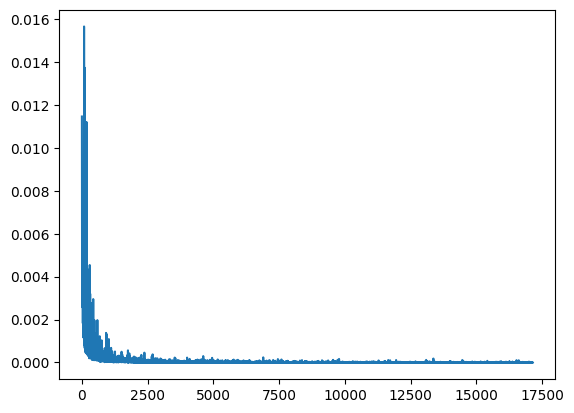

In [21]:
f = classifier.feature_importances_
plt.plot(f)

importance_rank = np.argsort(-f)

print('Most important words:')
for i in importance_rank[:20]:
  print(vocabulary[i])

print('\nLeast important words:')
for i in importance_rank[-20:]:
  print(vocabulary[i])

### Naive Bayes


In [22]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

classifier = MultinomialNB()
start = time.time()
classifier.fit(X_train, y_train)
end = time.time()
print('Elapsed time training= {:.4f} secs'.format(end-start))
start = time.time()
pred = classifier.predict(X_test)
end = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end-start))
print(f'Training set accuracy: {accuracy_score(y_train,classifier.predict(X_train)):6.4f}')
print(f'Accuracy: {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

Elapsed time training= 1.8159 secs
Elapsed time testing= 0.0793 secs
Training set accuracy: 0.9071
Accuracy: 0.8533
Confusion matrix:
[[ 63   5   9   3]
 [  2 359  18   5]
 [  0  72 384  12]
 [  1  36  38 363]]


In [23]:
classifier = GaussianNB()
start = time.time()
classifier.fit(X_train, y_train)
end = time.time()
print('Elapsed time training= {:.4f} secs'.format(end-start))
start = time.time()
pred = classifier.predict(X_test)
end = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end-start))
print(f'Training set accuracy: {accuracy_score(y_train,classifier.predict(X_train)):6.4f}')
print(f'Accuracy: {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

Elapsed time training= 1.2473 secs
Elapsed time testing= 0.6792 secs
Training set accuracy: 0.8542
Accuracy: 0.7577
Confusion matrix:
[[ 63   6  10   1]
 [ 14 287  75   8]
 [ 70  24 364  10]
 [ 31   7  76 324]]


In [24]:
classifier = BernoulliNB()
start = time.time()
classifier.fit(X_train, y_train)
end = time.time()
print('Elapsed time training= {:.4f} secs'.format(end-start))
start = time.time()
pred = classifier.predict(X_test)
end = time.time()
print('Elapsed time testing= {:.4f} secs'.format(end-start))
print(f'Training set accuracy: {accuracy_score(y_train,classifier.predict(X_train)):6.4f}')
print(f'Accuracy: {accuracy_score(y_test,pred):6.4f}')
print(f'Confusion matrix:\n{confusion_matrix(y_test,pred)}')

Elapsed time training= 2.6886 secs
Elapsed time testing= 0.2348 secs
Training set accuracy: 0.8003
Accuracy: 0.7438
Confusion matrix:
[[ 37   6  33   4]
 [  7 205 162  10]
 [  3  35 426   4]
 [  8   7  72 351]]


## Part 3: CountVectorizer, N-Grams, Binary Features, and TF-IDF

The next workflow uses scikit-learn's `CountVectorizer`. Here the train/test split is performed before fitting the vectorizer, so the vocabulary is learned from the training text only.

The experiments then study how the representation changes when:

- very rare and very common words are filtered,
- word counts are binarized,
- 2-word sequences are added,
- and TF-IDF weighting is applied.


In [25]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import bs4 as bs
import urllib.request
import numpy as np
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

### A Small Bag-of-Words Example


Some simple examples:

In [26]:
R1 = 'These socks looked good in the photo but they are pure trash.'
R2 = 'I have bought about 3 sets of these socks now; I love these socks!'

Using sklearn's count vectorizer, we obtain a numeric description of each text document.

In [27]:
count_vect = CountVectorizer()
word_counts = count_vect.fit_transform([R1,R2])
count_vect.fit([R1,R2])

CountVectorizer()

In [28]:
count_vect = CountVectorizer()
count_vect.fit([R1,R2])
print('Vocabulary:\n',count_vect.vocabulary_)
if hasattr(count_vect, 'stop_words_'):
    print('Stop words:\n',count_vect.stop_words_)
else:
    print('No stop words were explicitly set or found by the vectorizer.')

Vocabulary:
 {'these': 16, 'socks': 14, 'looked': 7, 'good': 4, 'in': 6, 'the': 15, 'photo': 11, 'but': 3, 'they': 17, 'are': 1, 'pure': 12, 'trash': 18, 'have': 5, 'bought': 2, 'about': 0, 'sets': 13, 'of': 10, 'now': 9, 'love': 8}
No stop words were explicitly set or found by the vectorizer.


Now the text data can be represented as a 2D array, as normally required by ML functions.

In [29]:
#word_counts = count_vect.transform([R1,R2]).todense()
word_counts = count_vect.transform([R1,R2])
print(word_counts)
print(word_counts.todense())

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 21 stored elements and shape (2, 19)>
  Coords	Values
  (0, 1)	1
  (0, 3)	1
  (0, 4)	1
  (0, 6)	1
  (0, 7)	1
  (0, 11)	1
  (0, 12)	1
  (0, 14)	1
  (0, 15)	1
  (0, 16)	1
  (0, 17)	1
  (0, 18)	1
  (1, 0)	1
  (1, 2)	1
  (1, 5)	1
  (1, 8)	1
  (1, 9)	1
  (1, 10)	1
  (1, 13)	1
  (1, 14)	2
  (1, 16)	2
[[0 1 0 1 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1]
 [1 0 1 0 0 1 0 0 1 1 1 0 0 1 2 0 2 0 0]]


Where word_counts[i,j] represents the number of times that word j in the vocabulary appears in document i.

### Three-Book Gutenberg Dataset


In [30]:
def get_paragraph_list(url,skip):
    paragraphs = []
    data = urllib.request.urlopen(url).read()
    soup = bs.BeautifulSoup(data,'lxml')
    for paragraph in soup.find_all('p'):
        par  = paragraph.get_text()
        if par:
            if len(par)>=30:
              paragraphs.append(par)
    return paragraphs[skip:]

url_list = ['http://www.gutenberg.org/files/215/215-h/215-h.htm', 'http://www.gutenberg.org/files/345/345-h/345-h.htm', 'http://www.gutenberg.org/files/1661/1661-h/1661-h.htm']

paragraphs = []
targets = []
first_par = []
skip = [1,4,0]
for u, url in enumerate(url_list):
    par = get_paragraph_list(url,skip[u])
    paragraphs = paragraphs + par
    targets = targets + [u for i in par]
    print('\nBook {} contains {} paragraphs'.format(u,len(par)))
    lengths = np.array([len(wl) for wl in par])
    print('Paragraph length stats:')
    print('min = {} max = {} mean = {:4f}'.format(np.min(lengths),np.max(lengths),np.mean(lengths)))
    print('First paragraph:')
    print(par[0])
    first_par.append(par[0])


Book 0 contains 327 paragraphs
Paragraph length stats:
min = 43 max = 1558 mean = 534.504587
First paragraph:

Buck did not read the newspapers, or he would have known that trouble was
brewing, not alone for himself, but for every tide-water dog, strong of muscle
and with warm, long hair, from Puget Sound to San Diego. Because men, groping
in the Arctic darkness, had found a yellow metal, and because steamship and
transportation companies were booming the find, thousands of men were rushing
into the Northland. These men wanted dogs, and the dogs they wanted were heavy
dogs, with strong muscles by which to toil, and furry coats to protect them
from the frost.


Book 1 contains 1745 paragraphs
Paragraph length stats:
min = 30 max = 4713 mean = 473.446418
First paragraph:
3 May. Bistritz.—Left Munich at 8:35 P. M., on 1st May, arriving at
Vienna early next morning; should have arrived at 6:46, but train was an
hour late. Buda-Pesth seems a wonderful place, from the glimpse which I
got of

Now let's split the data into training and test sets and find the bag-of-words representation of the data. Since we are not allowed to see the test data, the vectorizer must be fitted to the training data only.


In [31]:
x_train, x_test, y_train, y_test = train_test_split(paragraphs, targets, test_size=0.2, random_state=4361)

A randomly-chosen training example and its class:

In [32]:
i = np.random.randint(len(x_train))
print(x_train[i])
#print(y_train[i])

“The Pall Mall Gazette,” 18 September.


In [33]:
count_vect = CountVectorizer()
count_vect.fit(x_train)
x_train_counts = count_vect.transform(x_train)
x_test_counts = count_vect.transform(x_test)
print('Training set has {} examples, {} features'.format(x_train_counts.shape[0], x_train_counts.shape[1]))
print('Test set has {} examples, {} features'.format(x_test_counts.shape[0], x_test_counts.shape[1]))

Training set has 3362 examples, 12702 features
Test set has 841 examples, 12702 features


In [34]:
print('Vocabulary:', count_vect.vocabulary_.keys())
print('Sorted words in vocabulary:', sorted(list(count_vect.vocabulary_.keys())))
if hasattr(count_vect, 'stop_words_'):
    print('Stop words:', count_vect.stop_words_)
else:
    print('No stop words were explicitly set or found by the vectorizer.')

Vocabulary: dict_keys(['can', 'you', 'tell', 'me', 'why', 'the', 'tortoise', 'lives', 'more', 'long', 'than', 'generations', 'of', 'men', 'elephant', 'goes', 'on', 'and', 'till', 'he', 'have', 'seen', 'dynasties', 'parrot', 'never', 'die', 'only', 'bite', 'cat', 'or', 'dog', 'other', 'complaint', 'believe', 'in', 'all', 'ages', 'places', 'that', 'there', 'are', 'some', 'few', 'who', 'live', 'always', 'if', 'they', 'be', 'permit', 'women', 'cannot', 'we', 'know', 'because', 'science', 'has', 'vouched', 'for', 'fact', 'been', 'toads', 'shut', 'up', 'rocks', 'thousands', 'years', 'one', 'so', 'small', 'hole', 'hold', 'him', 'since', 'youth', 'world', 'how', 'indian', 'fakir', 'make', 'himself', 'to', 'buried', 'his', 'grave', 'sealed', 'corn', 'sowed', 'it', 'reaped', 'cut', 'sown', 'again', 'then', 'come', 'take', 'away', 'unbroken', 'seal', 'lie', 'not', 'dead', 'but', 'rise', 'walk', 'amongst', 'them', 'as', 'before', 'here', 'interrupted', 'was', 'getting', 'bewildered', 'crowded', 'm

Now let's classify the data

In [35]:
clf = MultinomialNB()
clf.fit(x_train_counts, y_train)
pred = clf.predict(x_test_counts)
print('Model accuracy: {:.4f}'.format(accuracy_score(y_test,pred)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))


Model accuracy: 0.9001
Confusion matrix:
 [[ 52   7   5]
 [  0 343  17]
 [  0  55 362]]


In [36]:
knn = KNeighborsClassifier()
knn.fit(x_train_counts, y_train)
pred = knn.predict(x_test_counts)
print('Model accuracy: {:.4f}'.format(accuracy_score(y_test,pred)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

Model accuracy: 0.6052
Confusion matrix:
 [[ 29  16  19]
 [  6 219 135]
 [  2 154 261]]


In [37]:
svc = SVC()
svc.fit(x_train_counts, y_train)
pred = svc.predict(x_test_counts)
print('Model accuracy: {:.4f}'.format(accuracy_score(y_test,pred)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

Model accuracy: 0.8216
Confusion matrix:
 [[ 40   4  20]
 [  1 252 107]
 [  0  18 399]]


In [38]:
model = RandomForestClassifier()
model.fit(x_train_counts, y_train)
pred = model.predict(x_test_counts)
print('Model accuracy: {:.4f}'.format(accuracy_score(y_test,pred)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

Model accuracy: 0.8300
Confusion matrix:
 [[ 42  11  11]
 [  0 275  85]
 [  0  36 381]]


### Remove Very Rare and Very Common Words


One problem with this approach is that words that appear too rarely or too often are normally not very informative.

We can see how to ignore them in the CountVectorizer() documentation.

https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html

In [39]:
count_vect = CountVectorizer(min_df=2, max_df = 0.3)
count_vect.fit(x_train)
x_train_counts = count_vect.transform(x_train)
x_test_counts = count_vect.transform(x_test)
print('Training set has {} examples, {} features'.format(x_train_counts.shape[0], x_train_counts.shape[1]))
print('Test set has {} examples, {} features'.format(x_test_counts.shape[0], x_test_counts.shape[1]))

Training set has 3362 examples, 7139 features
Test set has 841 examples, 7139 features


In [40]:
print('Vocabulary:', count_vect.vocabulary_.keys())
print('Sorted words in vocabulary:', sorted(list(count_vect.vocabulary_.keys())))
if hasattr(count_vect, 'stop_words_'):
    print('Stop words:', count_vect.stop_words_)
else:
    print('No stop words were explicitly set or found by the vectorizer.')

Vocabulary: dict_keys(['can', 'tell', 'me', 'why', 'lives', 'more', 'long', 'than', 'generations', 'men', 'elephant', 'goes', 'on', 'till', 'have', 'seen', 'never', 'die', 'only', 'bite', 'cat', 'or', 'dog', 'other', 'complaint', 'believe', 'all', 'ages', 'places', 'there', 'are', 'some', 'few', 'who', 'live', 'always', 'if', 'they', 'be', 'permit', 'women', 'cannot', 'we', 'know', 'because', 'science', 'has', 'fact', 'been', 'shut', 'up', 'rocks', 'thousands', 'years', 'one', 'so', 'small', 'hole', 'hold', 'him', 'since', 'youth', 'world', 'how', 'indian', 'make', 'himself', 'buried', 'grave', 'sealed', 'corn', 'reaped', 'cut', 'sown', 'again', 'then', 'come', 'take', 'away', 'unbroken', 'seal', 'lie', 'dead', 'rise', 'walk', 'amongst', 'them', 'before', 'here', 'interrupted', 'getting', 'bewildered', 'crowded', 'my', 'mind', 'list', 'nature', 'possible', 'imagination', 'fired', 'had', 'dim', 'idea', 'teaching', 'lesson', 'ago', 'used', 'do', 'study', 'amsterdam', 'thing', 'could', 'o

In [41]:
clf = MultinomialNB()
clf.fit(x_train_counts, y_train)
pred = clf.predict(x_test_counts)
print('NB accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

knn = KNeighborsClassifier()
knn.fit(x_train_counts, y_train)
pred = knn.predict(x_test_counts)
print('K-nn accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

svc = SVC()
svc.fit(x_train_counts, y_train)
pred = svc.predict(x_test_counts)
print('SVC accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

model = RandomForestClassifier()
model.fit(x_train_counts, y_train)
pred = model.predict(x_test_counts)
print('RF accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

NB accuracy: 0.8942
Confusion matrix:
 [[ 53   7   4]
 [  1 341  18]
 [  1  58 358]]
K-nn accuracy: 0.5434
Confusion matrix:
 [[  6  25  33]
 [  0 227 133]
 [  0 193 224]]
SVC accuracy: 0.8300
Confusion matrix:
 [[ 42   9  13]
 [  0 265  95]
 [  0  26 391]]
RF accuracy: 0.8549
Confusion matrix:
 [[ 48   8   8]
 [  0 293  67]
 [  0  39 378]]


### Binary Word-Presence Features


We can binarize features.

In [42]:
count_vect = CountVectorizer(min_df=2, max_df = 0.3,binary=True)
count_vect.fit(x_train)
x_train_counts = count_vect.transform(x_train)
x_test_counts = count_vect.transform(x_test)
print('Training set has {} examples, {} features'.format(x_train_counts.shape[0], x_train_counts.shape[1]))
print('Test set has {} examples, {} features'.format(x_test_counts.shape[0], x_test_counts.shape[1]))

Training set has 3362 examples, 7139 features
Test set has 841 examples, 7139 features


In [43]:
clf = MultinomialNB()
clf.fit(x_train_counts, y_train)
pred = clf.predict(x_test_counts)
print('NB accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

knn = KNeighborsClassifier()
knn.fit(x_train_counts, y_train)
pred = knn.predict(x_test_counts)
print('K-nn accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

svc = SVC()
svc.fit(x_train_counts, y_train)
pred = svc.predict(x_test_counts)
print('SVC accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

model = RandomForestClassifier()
model.fit(x_train_counts, y_train)
pred = model.predict(x_test_counts)
print('RF accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

NB accuracy: 0.9001
Confusion matrix:
 [[ 54   6   4]
 [  1 341  18]
 [  1  54 362]]
K-nn accuracy: 0.4721
Confusion matrix:
 [[  0  38  26]
 [  0 208 152]
 [  0 228 189]]
SVC accuracy: 0.8537
Confusion matrix:
 [[ 41  10  13]
 [  0 285  75]
 [  0  25 392]]
RF accuracy: 0.8478
Confusion matrix:
 [[ 45   7  12]
 [  0 294  66]
 [  0  43 374]]


### Add One-Word and Two-Word Features


We can add 2-word sequences to the vocabulary.

In [44]:
count_vect = CountVectorizer(min_df=2, max_df = 0.3, ngram_range=(1,2))
count_vect.fit(x_train)
x_train_counts = count_vect.transform(x_train)
x_test_counts = count_vect.transform(x_test)
print('Training set has {} examples, {} features'.format(x_train_counts.shape[0], x_train_counts.shape[1]))
print('Test set has {} examples, {} features'.format(x_test_counts.shape[0], x_test_counts.shape[1]))

Training set has 3362 examples, 30948 features
Test set has 841 examples, 30948 features


In [45]:
clf = MultinomialNB()
clf.fit(x_train_counts, y_train)
pred = clf.predict(x_test_counts)
print('NB accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

knn = KNeighborsClassifier()
knn.fit(x_train_counts, y_train)
pred = knn.predict(x_test_counts)
print('K-nn accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

svc = SVC()
svc.fit(x_train_counts, y_train)
pred = svc.predict(x_test_counts)
print('SVC accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

model = RandomForestClassifier()
model.fit(x_train_counts, y_train)
pred = model.predict(x_test_counts)
print('RF accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

NB accuracy: 0.9096
Confusion matrix:
 [[ 53   7   4]
 [  1 345  14]
 [  0  50 367]]
K-nn accuracy: 0.4459
Confusion matrix:
 [[  3  37  24]
 [  2 260  98]
 [  0 305 112]]
SVC accuracy: 0.8252
Confusion matrix:
 [[ 40  10  14]
 [  0 259 101]
 [  0  22 395]]
RF accuracy: 0.8383
Confusion matrix:
 [[ 42  11  11]
 [  0 284  76]
 [  0  38 379]]


### Add Binarization to the N-Gram Representation


And add binarization

In [46]:
count_vect = CountVectorizer(min_df=2, max_df = 0.3, ngram_range=(1,2),binary=True)
count_vect.fit(x_train)
x_train_counts = count_vect.transform(x_train)
x_test_counts = count_vect.transform(x_test)
print('Training set has {} examples, {} features'.format(x_train_counts.shape[0], x_train_counts.shape[1]))
print('Test set has {} examples, {} features'.format(x_test_counts.shape[0], x_test_counts.shape[1]))

clf = MultinomialNB()
clf.fit(x_train_counts, y_train)
pred = clf.predict(x_test_counts)
print('NB accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

knn = KNeighborsClassifier()
knn.fit(x_train_counts, y_train)
pred = knn.predict(x_test_counts)
print('K-nn accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

svc = SVC()
svc.fit(x_train_counts, y_train)
pred = svc.predict(x_test_counts)
print('SVC accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

model = RandomForestClassifier()
model.fit(x_train_counts, y_train)
pred = model.predict(x_test_counts)
print('RF accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

Training set has 3362 examples, 30948 features
Test set has 841 examples, 30948 features
NB accuracy: 0.9180
Confusion matrix:
 [[ 54   6   4]
 [  1 343  16]
 [  0  42 375]]
K-nn accuracy: 0.4043
Confusion matrix:
 [[  0  64   0]
 [  0 320  40]
 [  0 397  20]]
SVC accuracy: 0.8395
Confusion matrix:
 [[ 39  11  14]
 [  0 272  88]
 [  0  22 395]]
RF accuracy: 0.8407
Confusion matrix:
 [[ 44  10  10]
 [  0 281  79]
 [  0  35 382]]


### TF-IDF Representation


In addition to using a bag-of-words representation, we can use **TFIDF**, the **term frequency–inverse document frequency**, a numerical statistic that is intended to reflect how important a word is to a document in a collection.

See https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

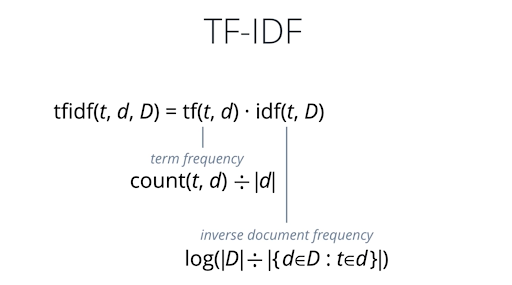

In [47]:
count_vect = CountVectorizer(min_df=2, max_df = 0.3, ngram_range=(1,2))
count_vect.fit(x_train)
x_train_counts = count_vect.transform(x_train)
x_test_counts = count_vect.transform(x_test)
print('Training set has {} examples, {} features'.format(x_train_counts.shape[0], x_train_counts.shape[1]))
print('Test set has {} examples, {} features'.format(x_test_counts.shape[0], x_test_counts.shape[1]))

tfidf_transformer = TfidfTransformer()
x_train_counts = tfidf_transformer.fit_transform(x_train_counts)
x_test_counts = tfidf_transformer.transform(x_test_counts)

clf = MultinomialNB()
clf.fit(x_train_counts, y_train)
pred = clf.predict(x_test_counts)
print('NB accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

knn = KNeighborsClassifier()
knn.fit(x_train_counts, y_train)
pred = knn.predict(x_test_counts)
print('K-nn accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

svc = SVC()
svc.fit(x_train_counts, y_train)
pred = svc.predict(x_test_counts)
print('SVC accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

model = RandomForestClassifier()
model.fit(x_train_counts, y_train)
pred = model.predict(x_test_counts)
print('RF accuracy: {:.4f}'.format(accuracy_score(pred,y_test)))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))

Training set has 3362 examples, 30948 features
Test set has 841 examples, 30948 features
NB accuracy: 0.8585
Confusion matrix:
 [[  2  33  29]
 [  0 329  31]
 [  0  26 391]]
K-nn accuracy: 0.4281
Confusion matrix:
 [[  0  64   0]
 [  0 360   0]
 [  0 417   0]]
SVC accuracy: 0.8882
Confusion matrix:
 [[ 43   4  17]
 [  0 302  58]
 [  0  15 402]]
RF accuracy: 0.8335
Confusion matrix:
 [[ 41  11  12]
 [  0 278  82]
 [  0  35 382]]


## Classifier and Vectorizer Tuning

A useful next experiment is to select a classifier and jointly test different classifier settings and text-representation choices, including vocabulary filtering, n-gram range, binary features, and TF-IDF weighting.


## Key Takeaways

- Raw text must be transformed into numerical features before conventional machine learning models can use it.
- Cleaning and tokenization determine what units become candidate vocabulary terms.
- A vocabulary maps words to fixed feature positions.
- Bag-of-words preserves word occurrence information but does not preserve full word order.
- N-grams recover some local ordering information.
- TF-IDF down-weights terms that are common across many documents.
- The representation and the classifier both influence text-classification performance.
